In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as splat
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import os

from rubin_sim.splat.plots import bright_filter_colors

from rubin_sim.data import get_baseline
from os.path import basename
import glob


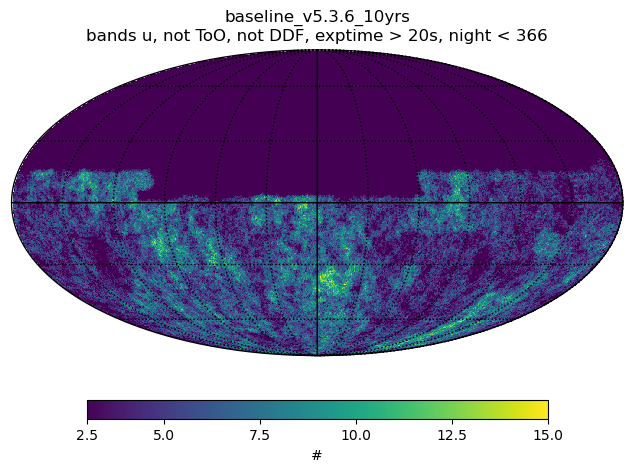

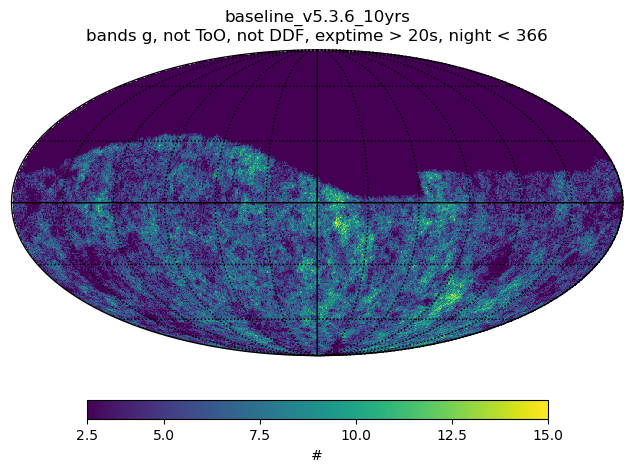

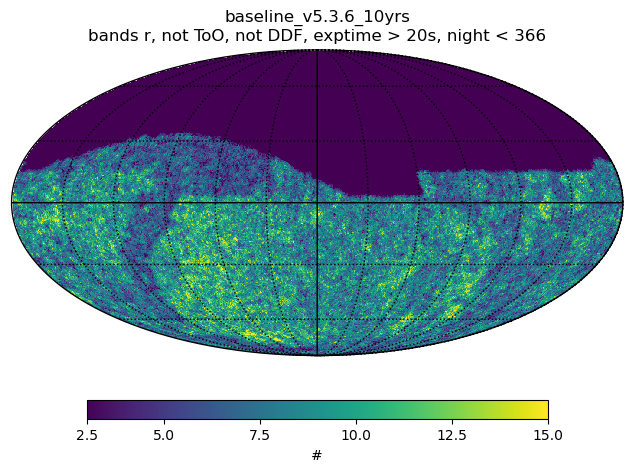

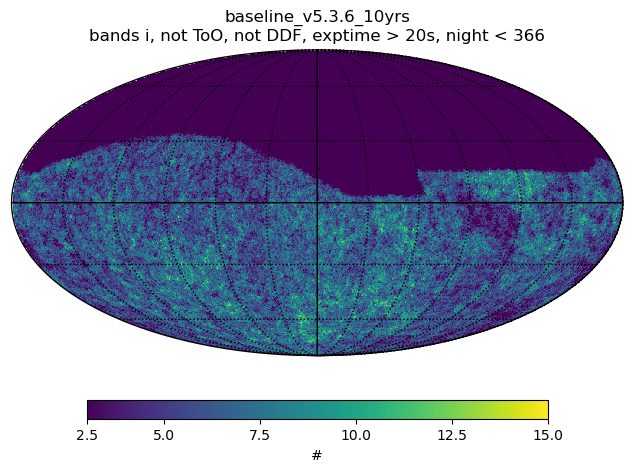

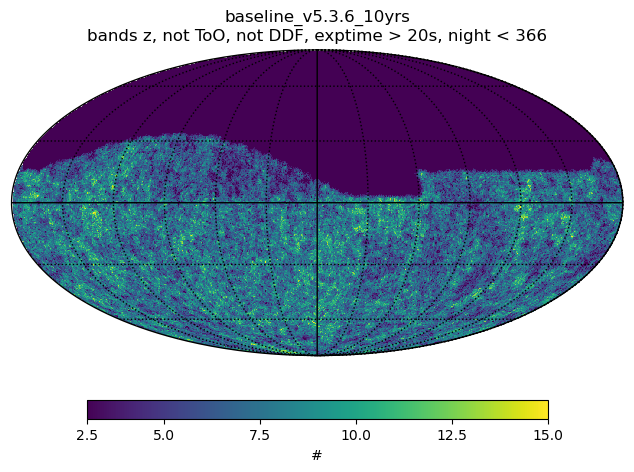

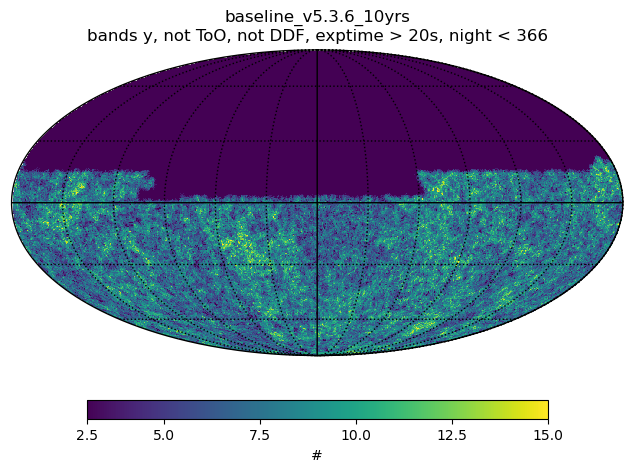

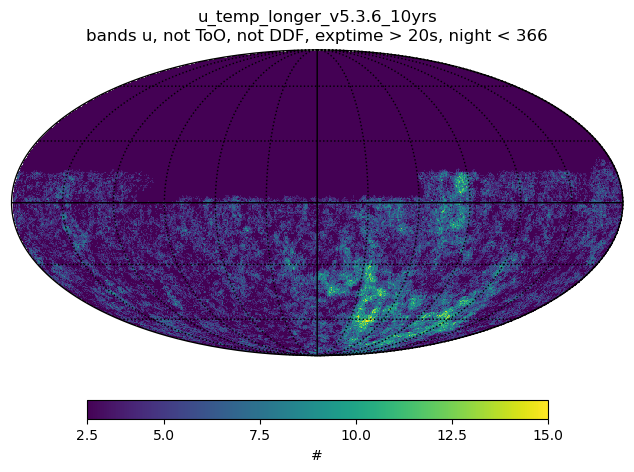

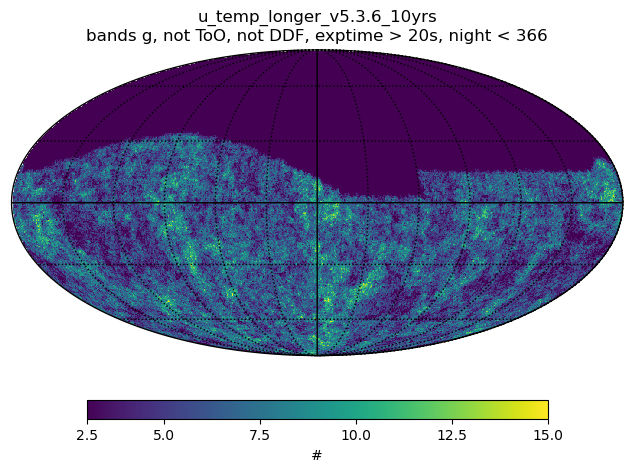

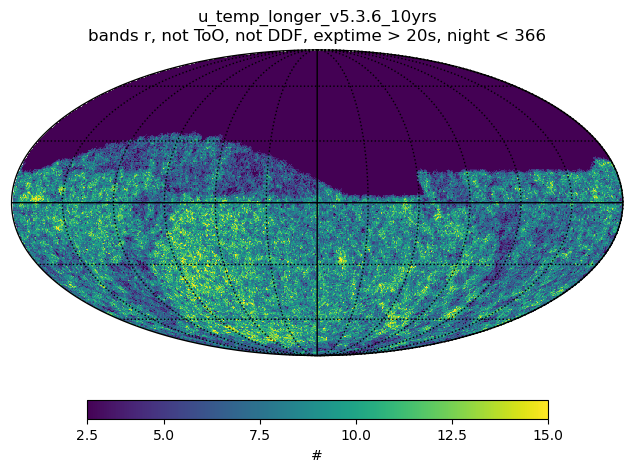

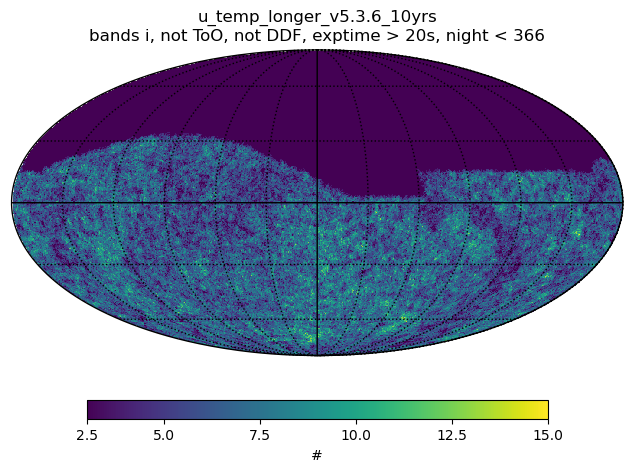

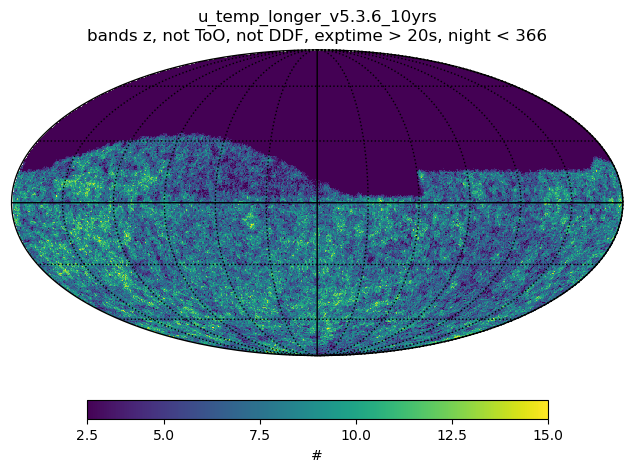

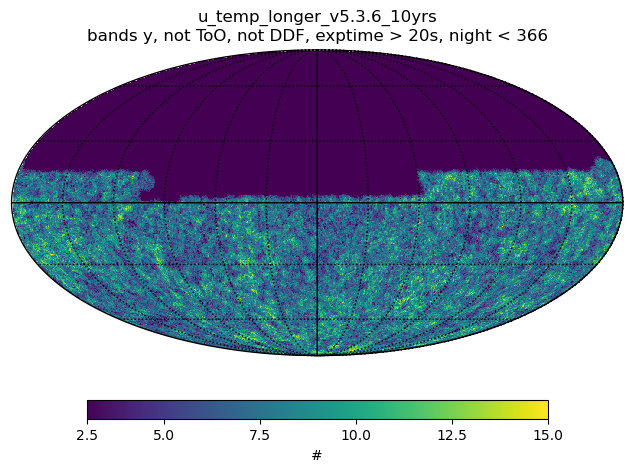

In [2]:
db_files = glob.glob("*10yrs.db")
db_files.sort()
fig_saver = splat.FigSaver(close_figs=False)

stats = []

for db_file in db_files:

    run_name = basename(db_file).replace('.db', '')
    con = sqlite3.connect(db_file)
    df = pd.read_sql('select * from observations where night < 366;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)

    for band in "ugrizy":
        info = {"data_source": run_name}
        info["observations_subset"] = "bands %s, not ToO, not DDF, exptime > 20s, night < 366" % band
        not_too = np.array(["ToO" not in note for note in visits_array["scheduler_note"]])
        not_ddf = np.array(["DD" not in note for note in visits_array["scheduler_note"]])
        indx = np.where((not_too == True) & (visits_array["visitExposureTime"] >= 20.)
                       & (not_ddf == True) & (visits_array["band"] == band))
        sub_data = visits_array[indx]
        metric = splat.CountMetric()
        sl = splat.Slicer(nside=128, missing=0)
        hp_array, info = sl(sub_data, metric, info=info)
        pm = splat.PlotMoll(info=info)
        fig = pm(hp_array, min=3, max=15)
        #nside = hp.npix2nside(hp_array.size)
    
        #wfd_pix = np.where( hp_array > 600)[0]
        #area = hp.nside2pixarea(nside, degrees=True)* wfd_pix.size
    
        #stats.append([run_name, np.median(hp_array[wfd_pix]), area])
    


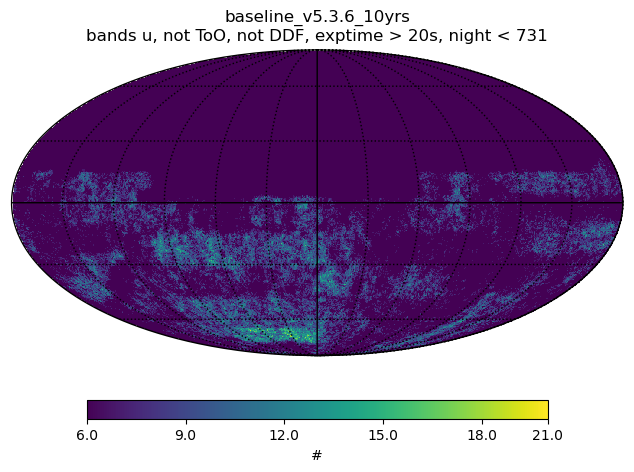

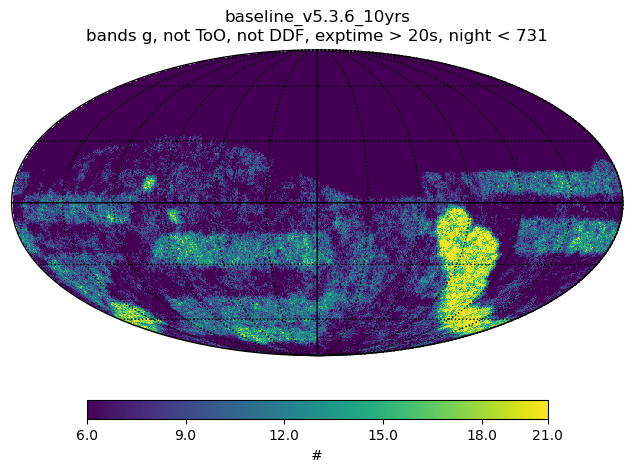

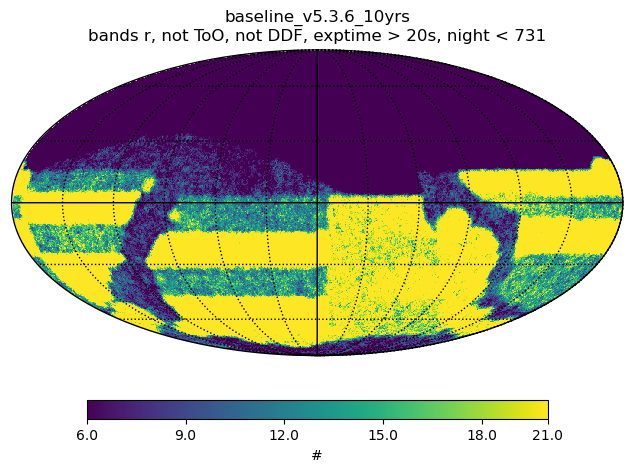

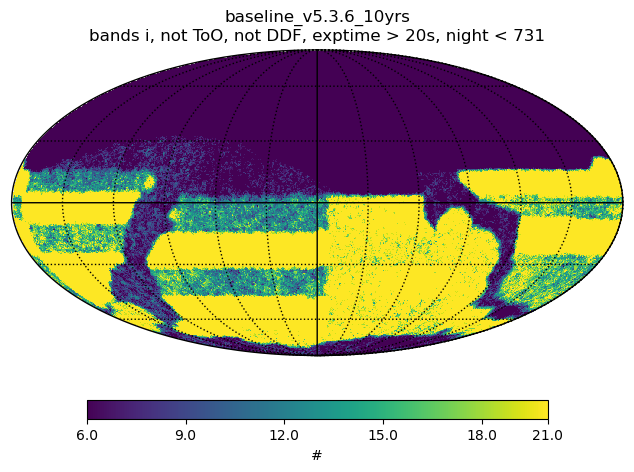

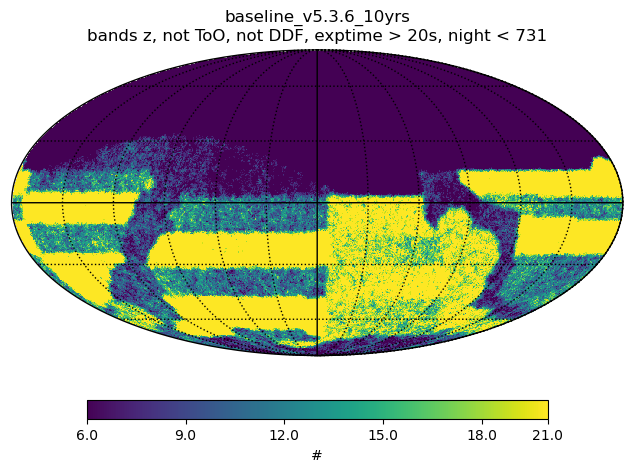

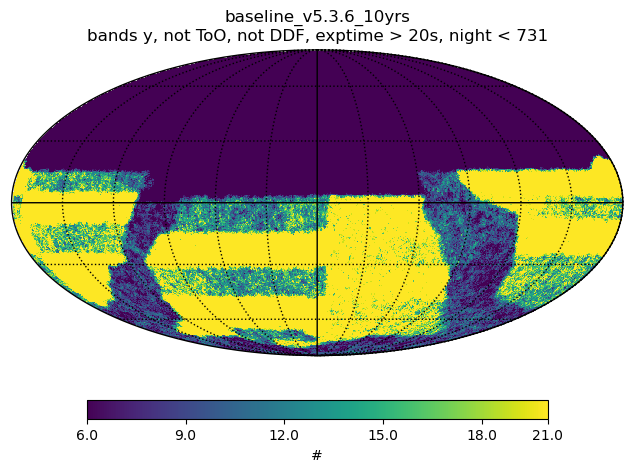

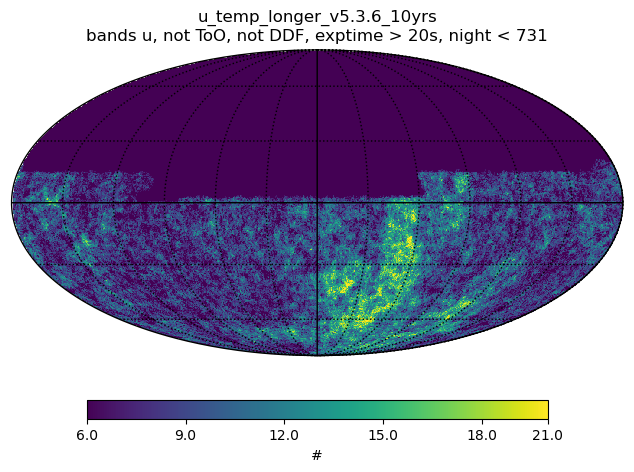

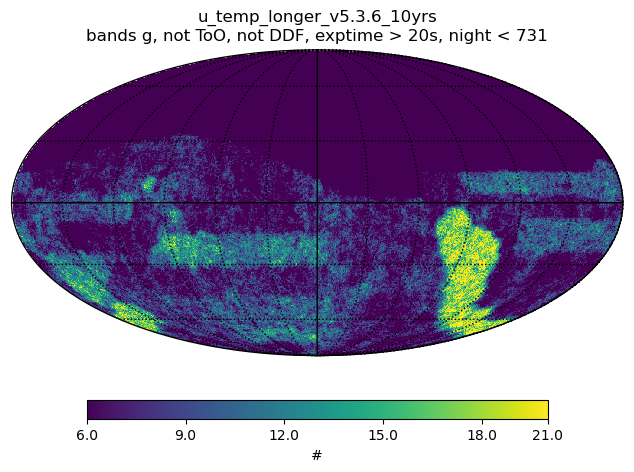

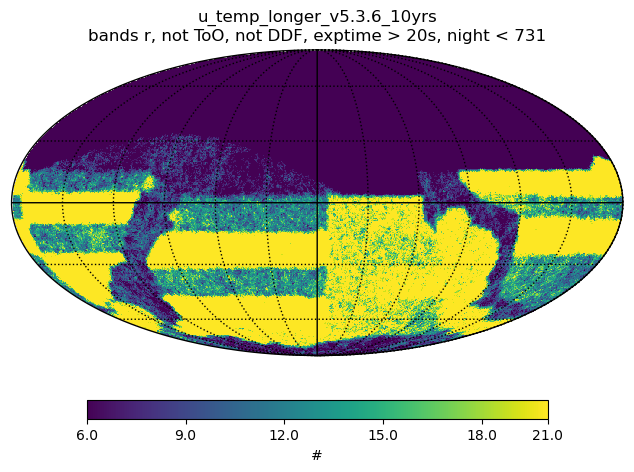

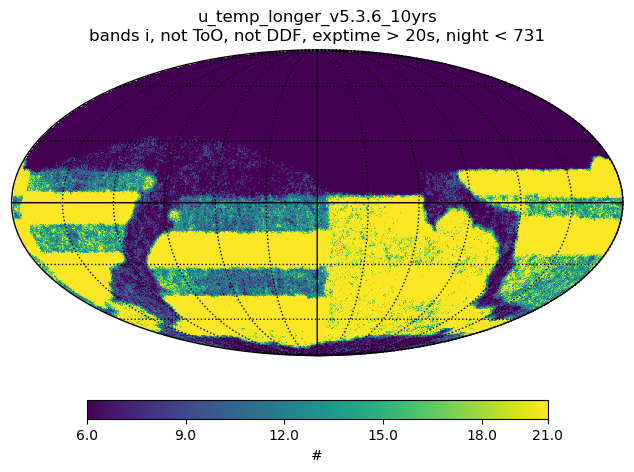

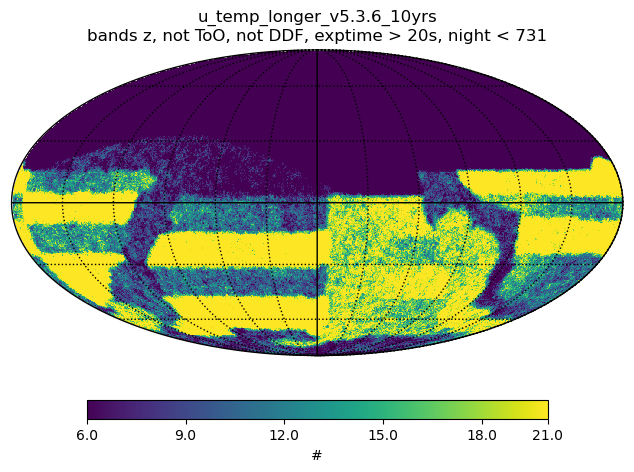

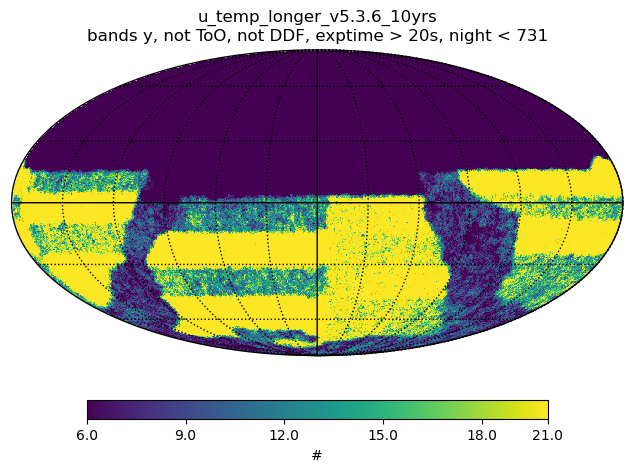

In [3]:
for db_file in db_files:

    run_name = basename(db_file).replace('.db', '')
    con = sqlite3.connect(db_file)
    df = pd.read_sql('select * from observations where night < 731;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)

    for band in "ugrizy":
        info = {"data_source": run_name}
        info["observations_subset"] = "bands %s, not ToO, not DDF, exptime > 20s, night < 731" % band
        not_too = np.array(["ToO" not in note for note in visits_array["scheduler_note"]])
        not_ddf = np.array(["DD" not in note for note in visits_array["scheduler_note"]])
        indx = np.where((not_too == True) & (visits_array["visitExposureTime"] >= 20.)
                       & (not_ddf == True) & (visits_array["band"] == band))
        sub_data = visits_array[indx]
        metric = splat.CountMetric()
        sl = splat.Slicer(nside=128, missing=0)
        hp_array, info = sl(sub_data, metric, info=info)
        pm = splat.PlotMoll(info=info)
        fig = pm(hp_array, min=6, max=20)
        #nside = hp.npix2nside(hp_array.size)
    
        #wfd_pix = np.where( hp_array > 600)[0]
        #area = hp.nside2pixarea(nside, degrees=True)* wfd_pix.size
    
        #stats.append([run_name, np.median(hp_array[wfd_pix]), area])
    

In [ ]:
for db in db_files:
    